### ============================================================
# EDA
### ============================================================


### -----------------------
### 1) Load data
### -----------------------

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "data/csv/processed.csv"   

df = pd.read_csv(path)

print("Shape:", df.shape)
display(df.head())

Shape: (986, 8)


,report_year,report_week,district,disease,category,cases,source_pdf,uid
0,2010,1,Dharashiv,Acute diarrhoeal disease,water-borne,55,1st_wk10.pdf,NaN
1,2010,2,Sangli,Acute diarrhoeal disease,water-borne,50,2nd_wk10.pdf,NaN
2,2010,4,Beed,Dengue,vector-borne,8,4th_wk10.pdf,NaN
3,2010,6,Ratnagiri,Acute diarrhoeal disease,water-borne,14,6th_wk10.pdf,NaN
4,2010,7,Dhule,Malaria,vector-borne,24,7th_wk10.pdf,NaN


### -----------------------
### 2) Basic info + quality checks
### -----------------------

In [3]:

print("\nColumns:", df.columns.tolist())
display(df.describe(include="all").T)

print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing"))

print("\nDuplicate rows (full row):", df.duplicated().sum())

### Duplicates on key columns (common in PDF parsing)
key_cols = ["report_year","report_week","district","disease","category","cases"]
if all(c in df.columns for c in key_cols):
    print("Duplicate rows (key_cols):", df.duplicated(subset=key_cols).sum())


Columns: ['report_year', 'report_week', 'district', 'disease', 'category', 'cases', 'source_pdf', 'uid']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
report_year,986.0,NaN,NaN,NaN,2019.581136,3.923638,2010.0,2017.0,2020.0,2023.0,2025.0
report_week,986.0,NaN,NaN,NaN,29.572008,13.574214,1.0,21.0,30.0,40.0,53.0
district,986,34,Kolhapur,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disease,986,24,Dengue,403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,986,3,vector-borne,672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cases,986.0,NaN,NaN,NaN,33.006085,192.135041,1.0,7.0,13.0,28.0,5825.0
source_pdf,986,450,17113853891702917780.pdf,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uid,759,759,MH/GAD/2017/2/0038,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values per column:


,missing
report_year,0
report_week,0
district,0
disease,0
category,0
cases,0
source_pdf,0
uid,227



Duplicate rows (full row): 0
Duplicate rows (key_cols): 12


### -----------------------
### 3) Make a proper week date column (ISO week)
### -----------------------

In [4]:
def iso_week_start(y, w):
    try:
        return pd.Timestamp.fromisocalendar(int(y), int(w), 1)  ### Monday
    except:
        return pd.NaT

df["week_start"] = [iso_week_start(y, w) for y, w in zip(df["report_year"], df["report_week"])]
df = df.dropna(subset=["week_start"]).copy()

print("\nDate range:", df["week_start"].min(), "→", df["week_start"].max())


Date range: 2010-01-04 00:00:00 → 2025-09-29 00:00:00


### -----------------------
### 4) Categorical overview
### -----------------------

In [5]:
for col in ["district","disease","category"]:
    if col in df.columns:
        print(f"\nUnique {col}:", df[col].nunique())

### Top districts and diseases by total cases
if "cases" in df.columns:
    df["cases"] = pd.to_numeric(df["cases"], errors="coerce")
    top_districts = df.groupby("district")["cases"].sum().sort_values(ascending=False).head(10)
    top_diseases  = df.groupby("disease")["cases"].sum().sort_values(ascending=False).head(10)

    print("\nTop 10 districts by total cases:")
    display(top_districts.to_frame("total_cases"))

    print("\nTop 10 diseases by total cases:")
    display(top_diseases.to_frame("total_cases"))


Unique district: 34

Unique disease: 24

Unique category: 3

Top 10 districts by total cases:


,total_cases
district,
Chhatrapati Sambhajinagar,6441
Gadchiroli,3015
Kolhapur,2512
Nagpur,2401
Nashik,2012
Jalgaon,1371
Satara,1059
Parbhani,1056
Amravati,895



Top 10 diseases by total cases:


,total_cases
disease,
Cholera,9198
Dengue,7994
Acute diarrhoeal disease,5362
Malaria,3536
Chikungunya,2124
Acute gastroenteritis,1275
Hepatitis A,739
Chickenpox,534
Dysentery,515


### -----------------------
### 5) Distribution of cases (very important)
### -----------------------

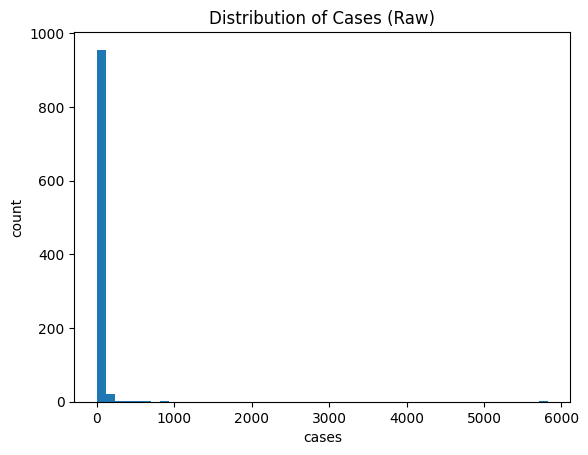

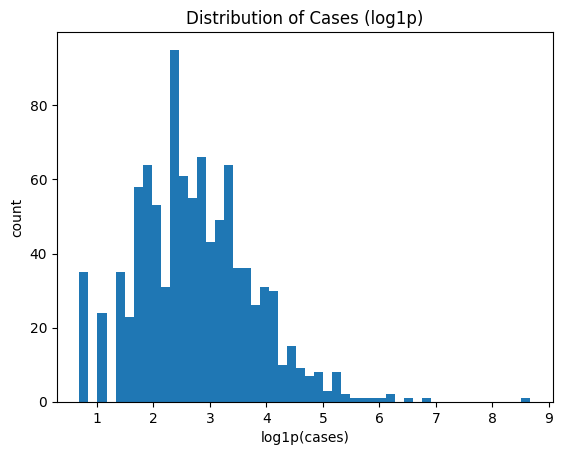

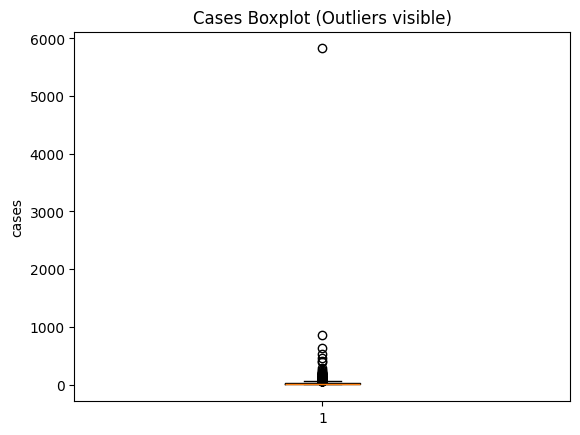

In [6]:
plt.figure()
plt.hist(df["cases"].dropna(), bins=50)
plt.title("Distribution of Cases (Raw)")
plt.xlabel("cases")
plt.ylabel("count")
plt.show()

### log scale distribution (usually clearer)
plt.figure()
plt.hist(np.log1p(df["cases"].dropna()), bins=50)
plt.title("Distribution of Cases (log1p)")
plt.xlabel("log1p(cases)")
plt.ylabel("count")
plt.show()

### Boxplot (outliers)
plt.figure()
plt.boxplot(df["cases"].dropna(), vert=True)
plt.title("Cases Boxplot (Outliers visible)")
plt.ylabel("cases")
plt.show()

### -----------------------
### 6) Trend over time (weekly aggregation)
### -----------------------

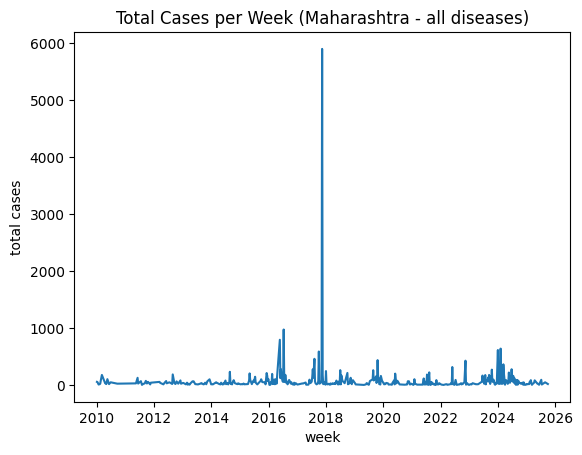

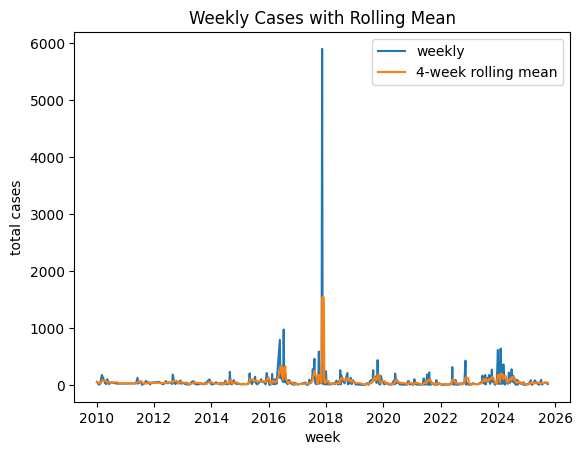

In [7]:
weekly_total = df.groupby("week_start")["cases"].sum().sort_index()

plt.figure()
plt.plot(weekly_total.index, weekly_total.values)
plt.title("Total Cases per Week (Maharashtra - all diseases)")
plt.xlabel("week")
plt.ylabel("total cases")
plt.show()

### Smoothed rolling average
plt.figure()
plt.plot(weekly_total.index, weekly_total.values, label="weekly")
plt.plot(weekly_total.index, weekly_total.rolling(4, min_periods=1).mean().values, label="4-week rolling mean")
plt.title("Weekly Cases with Rolling Mean")
plt.xlabel("week")
plt.ylabel("total cases")
plt.legend()
plt.show()

### -----------------------
### 7) Seasonality: cases by week number (1..53)
### -----------------------

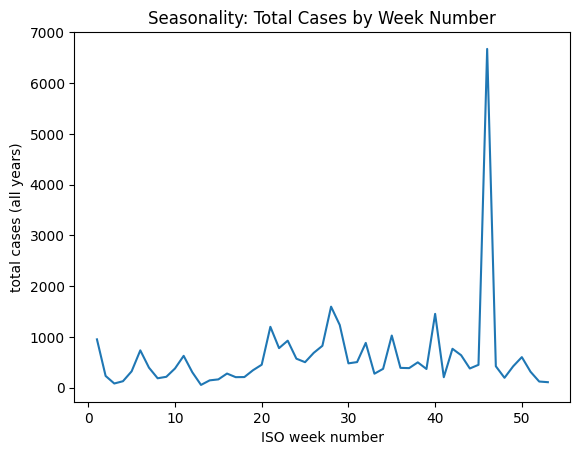

In [8]:
season = df.groupby("report_week")["cases"].sum().sort_index()

plt.figure()
plt.plot(season.index, season.values)
plt.title("Seasonality: Total Cases by Week Number")
plt.xlabel("ISO week number")
plt.ylabel("total cases (all years)")
plt.show()

### -----------------------
### 8) Category analysis (vector/water/air)
### -----------------------

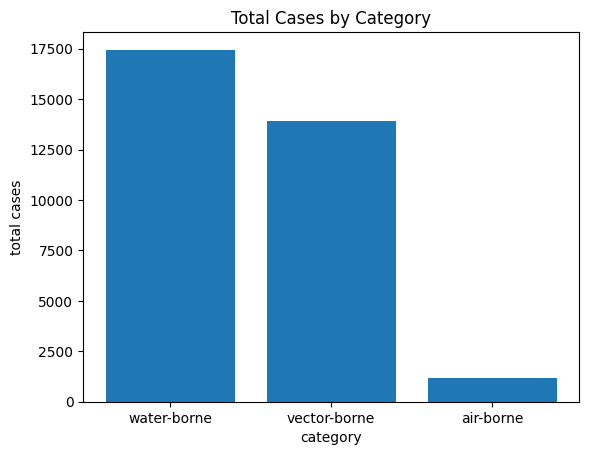

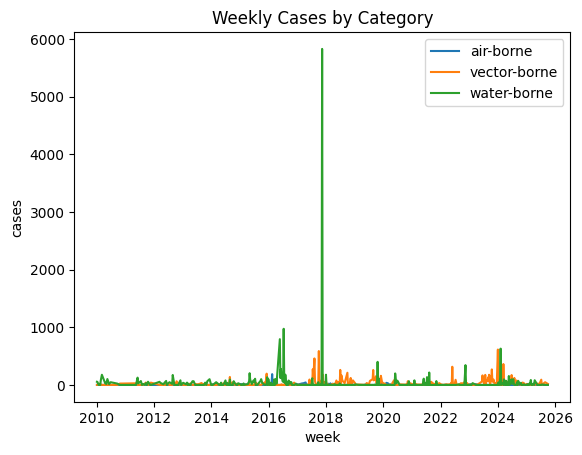

In [9]:
if "category" in df.columns:
    cat_total = df.groupby("category")["cases"].sum().sort_values(ascending=False)

    plt.figure()
    plt.bar(cat_total.index.astype(str), cat_total.values)
    plt.title("Total Cases by Category")
    plt.xlabel("category")
    plt.ylabel("total cases")
    plt.show()

    ### time trend by category
    weekly_cat = df.groupby(["week_start","category"])["cases"].sum().reset_index()
    pivot = weekly_cat.pivot(index="week_start", columns="category", values="cases").fillna(0).sort_index()

    plt.figure()
    for c in pivot.columns:
        plt.plot(pivot.index, pivot[c].values, label=str(c))
    plt.title("Weekly Cases by Category")
    plt.xlabel("week")
    plt.ylabel("cases")
    plt.legend()
    plt.show()

### -----------------------
### 9) Heatmap: district vs disease (total cases)
### -----------------------


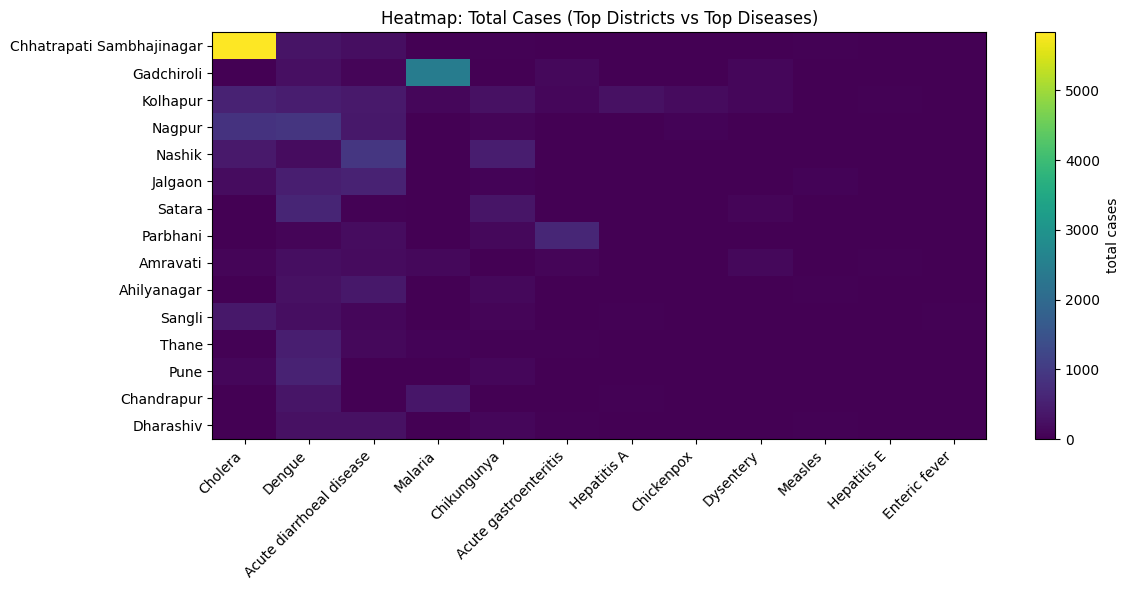

In [10]:
pivot_dd = df.pivot_table(index="district", columns="disease", values="cases", aggfunc="sum", fill_value=0)

### To keep it readable, take top 15 districts and top 12 diseases by total cases
top_d = df.groupby("district")["cases"].sum().sort_values(ascending=False).head(15).index
top_dis = df.groupby("disease")["cases"].sum().sort_values(ascending=False).head(12).index
heat = pivot_dd.loc[top_d, top_dis]

plt.figure(figsize=(12, 6))
plt.imshow(heat.values, aspect="auto")
plt.title("Heatmap: Total Cases (Top Districts vs Top Diseases)")
plt.xticks(range(len(heat.columns)), heat.columns, rotation=45, ha="right")
plt.yticks(range(len(heat.index)), heat.index)
plt.colorbar(label="total cases")
plt.tight_layout()
plt.show()

### -----------------------
### 10)Top disease trends (Top 3 diseases)
### -----------------------

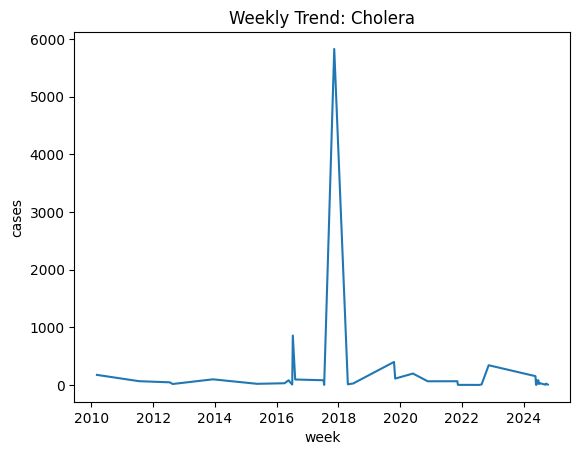

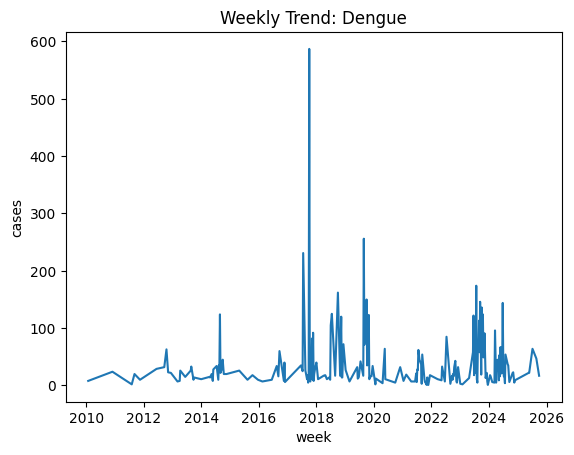

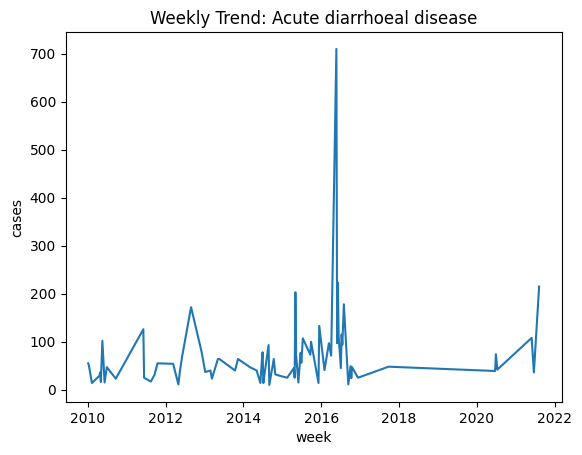

In [11]:
top3 = df.groupby("disease")["cases"].sum().sort_values(ascending=False).head(3).index.tolist()
for dis in top3:
    s = df[df["disease"] == dis].groupby("week_start")["cases"].sum().sort_index()
    plt.figure()
    plt.plot(s.index, s.values)
    plt.title(f"Weekly Trend: {dis}")
    plt.xlabel("week")
    plt.ylabel("cases")
    plt.show()

### -----------------------
### 11) Simple summary table for slides
### -----------------------

In [12]:
summary = pd.DataFrame({
    "rows": [len(df)],
    "years_min": [df["report_year"].min()],
    "years_max": [df["report_year"].max()],
    "unique_districts": [df["district"].nunique()],
    "unique_diseases": [df["disease"].nunique()],
    "total_cases": [df["cases"].sum()],
    "median_cases": [df["cases"].median()],
    "max_cases": [df["cases"].max()],
})
display(summary)

,rows,years_min,years_max,unique_districts,unique_diseases,total_cases,median_cases,max_cases
0,986,2010,2025,34,24,32544,13.0,5825
